## Simple LLM QA Workflow
```START -> LLM_QA -> END
             /  \
           Q:?  A:

In [8]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

model = ChatOpenAI()

### Step 1: Create a State

In [9]:
class LLMState(TypedDict):
    question: str
    answer: str

### Step 2: Create Graph

In [10]:
graph = StateGraph(LLMState)

### Step 3: Create your Node

In [13]:
def LLM_QA(state: LLMState) -> LLMState:
    # extract question from state
    question = state['question']

    # form a question
    prompt = f'Answer the following {question} asked by the user'

    # ask the question to the LLM
    answer = model.invoke(prompt).content

    # update the asnwer to the state
    state['answer'] = answer

    return state


graph.add_node(LLM_QA, 'LLM_QA')

### Step 4: Define Edges

In [15]:
graph.add_edge(START, 'LLM_QA')
graph.add_edge('LLM_QA', END)

### Step 5: Compile Graph

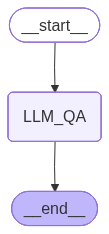

In [23]:
workflow = graph.compile()
graph.compile()

### Step 6: Execution Graph

In [24]:
initial_state = {'question':'How for is Bidar from Bangalore?'}
final_state = workflow.invoke(initial_state)
print(final_state)

{'question': 'How for is Bidar from Bangalore?', 'answer': 'Bidar is located approximately 675 kilometers (420 miles) from Bangalore.'}
